# Marketing A/B Testing
This project analyzes the results of a marketing A/B test designed to evaluate the impact of advertisements on user conversion behavior. The analysis compares conversion rates between users exposed to advertisements and those shown a public service announcement, using statistical testing, segmentation analysis and regression modeling.

Data source: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing

In [1]:
import pandas as pd
import numpy as np

## Data information

In [2]:
data = pd.read_csv('marketing_AB.csv')

In [3]:
data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


### Variables Description

- **user_id** – Unique identifier for each user.

- **test_group** – Experimental group assignment:
  - `ad` – the user was shown advertisements  
  - `psa` – the user was shown a public service announcement (control group)

- **converted** – Indicates whether the user purchased the product:
  - `True` – purchase occurred  
  - `False` – no purchase

- **total_ads** – Total number of advertisements shown to the user.

- **most_ads_day** – Day of the week when the user saw the highest number of ads.

- **most_ads_hour** – Hour of the day when the user saw the highest number of ads.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [5]:
# user id 
data.duplicated('user id').sum()

0

In [6]:
data=data.drop(columns=['user id','Unnamed: 0'])

In [7]:
data.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


### Variables Distribution

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
cat_variable=['test group','converted','most ads day']

In [10]:
for var in cat_variable:
    print(data[var].value_counts())
    print("\n")

test group
ad     564577
psa     23524
Name: count, dtype: int64


converted
False    573258
True      14843
Name: count, dtype: int64


most ads day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64




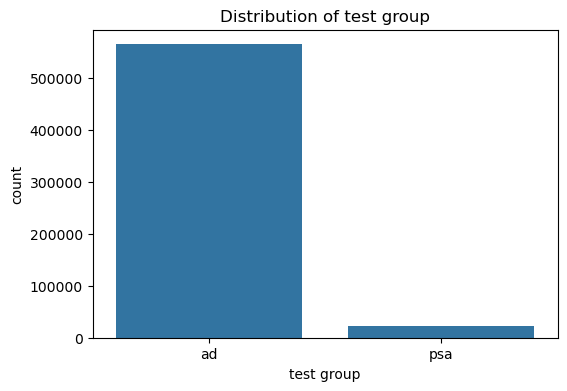

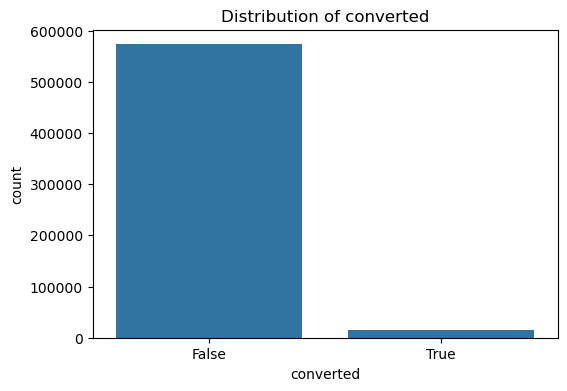

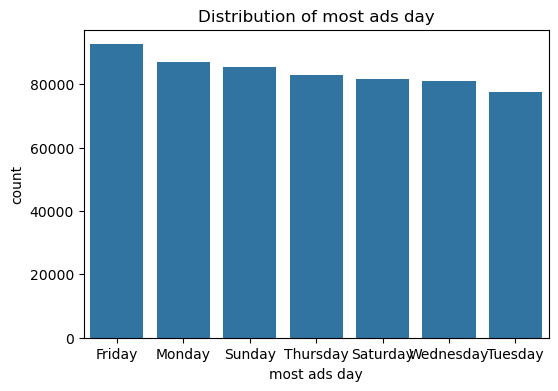

In [11]:
for var in cat_variable:
    plt.figure(figsize=(6,4))
    order = data[var].value_counts().index
    sns.countplot(data=data, x=var, order=order)
    plt.title(f'Distribution of {var}')
    plt.show()

- The dataset is highly imbalanced in terms of group sizes. The majority of users belong to the **ad group** (test group), while only a small fraction of users are in the **psa group** (control group).

- Conversions are rare in the dataset. The vast majority of observations correspond to **non-converted users**, while only a small proportion of users completed a purchase.

- Ad exposure appears to be relatively evenly distributed across the days of the week, although **Friday has the highest frequency**.

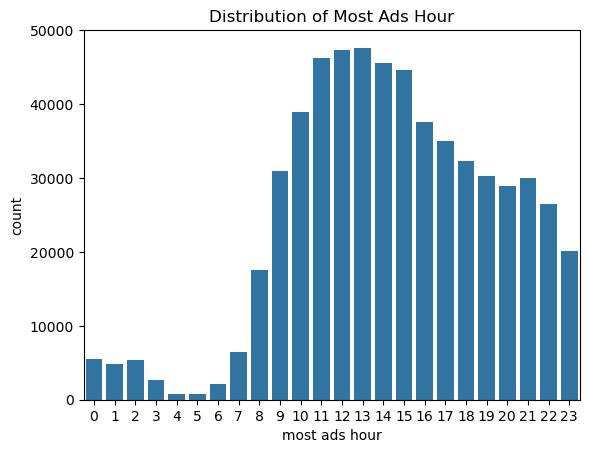

In [12]:
# Although "most ads hour" is stored as a numeric variable, it represents discrete time categories (hours of the day).
sns.countplot(data=data, x="most ads hour")
plt.title("Distribution of Most Ads Hour")
plt.show()

- The highest exposure to advertisements occurs during the middle of the day. 

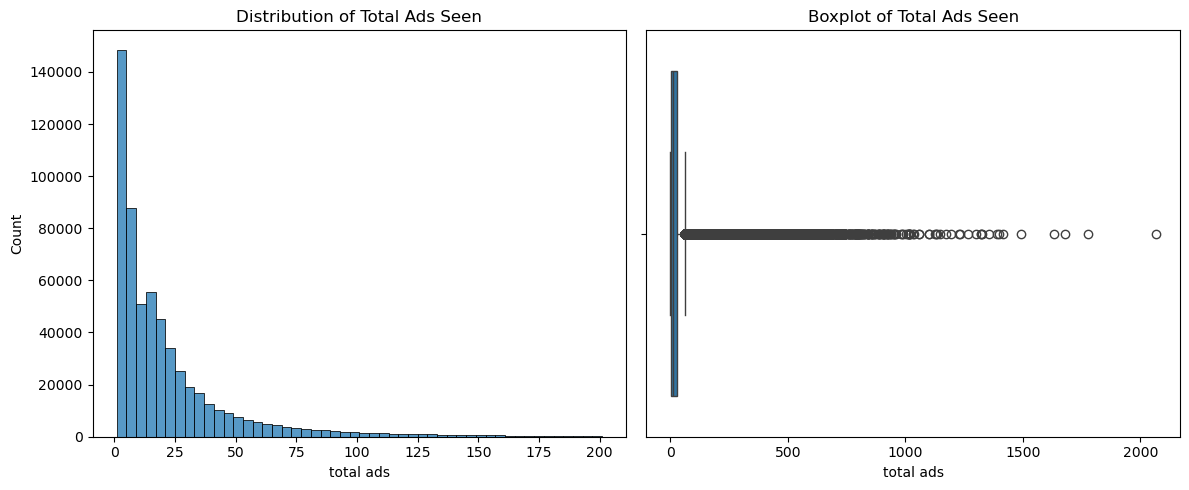

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
sns.histplot(data[data["total ads"] < data["total ads"].quantile(0.99)], x="total ads", bins=50, ax=axes[0])
axes[0].set_title("Distribution of Total Ads Seen")

# Boxplot
sns.boxplot(data=data, x="total ads", ax=axes[1])
axes[1].set_title("Boxplot of Total Ads Seen")

plt.tight_layout()
plt.show()

- The distribution of **total_ads** is highly right-skewed what can be seen on both plots
- Most users were exposed to a relatively small number of advertisements, while a small fraction of users experienced very high ad exposure.

## Sample Ratio Mismatch (SRM)

Before analyzing the experiment results, it is important to verify whether users were correctly assigned to the experimental groups. Sample Ratio Mismatch (SRM) occurs when the observed allocation of users across experimental groups significantly differs from the expected distribution.

However, the expected traffic split between the control and treatment groups is not provided in the dataset. Based on the distribution of the `test_group` variable, the allocation clearly does not follow a 50:50 split.

Since the intended experimental design (expected allocation ratio) is unknown, it is not possible to formally test for Sample Ratio Mismatch in this case.

In [14]:
observed = data["test group"].value_counts(normalize=True)*100
observed

test group
ad     96.000007
psa     3.999993
Name: proportion, dtype: float64

## Converstion rate analysis

In [15]:
conversion_summary = data.groupby("test group")["converted"].agg(
    users="count",
    conversions="sum",
    conversion_rate="mean"
)

conversion_summary

,users,conversions,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


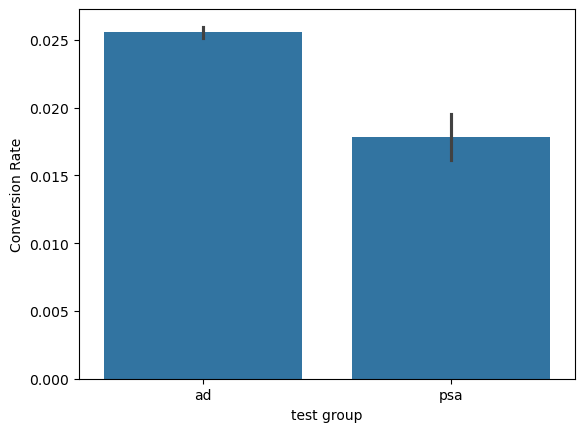

In [16]:
sns.barplot(data=data, x="test group", y="converted")
plt.ylabel("Conversion Rate")
plt.show()

The conversion rate is higher in the **ad group** compared to the **psa group**. However, statistical testing is required to determine whether this difference is statistically significant.

## Campaign lift

In [17]:
cr = data.groupby("test group")["converted"].mean()

lift = ((cr["ad"] - cr["psa"]) / cr["psa"])*100
lift

43.085064022225836

Lift indicates that the conversion rate in the **ad group** is approximately **43% higher** than in the **PSA group**.

## Hypothesis Testing
- H0: The conversion rates are equal for both groups
- H1: The conversion rates differ between the groups (test vs control)

To evaluate it, a two-proportion z-test will be used. The reasons for that are: 
- the outcome variable (conversion) is binary and the metric of interest is the difference between two proportions
- we have large sample size in the dataset, the normal approximation of the binomial distribution is valid

In [18]:
conversions = data.groupby("test group")["converted"].sum()
users = data.groupby("test group")["converted"].count()

In [19]:
# z-test

from statsmodels.stats.proportion import proportions_ztest

stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users,
    alternative="two-sided"
)

print("z-statistic:", round(stat, 3))
print("p-value:",  round(p_value, 6))


z-statistic: 7.37
p-value: 0.0


In [20]:
# Confidence Interval

p1 = cr["ad"]
p2 = cr["psa"]

n1 = users["ad"]
n2 = users["psa"]

diff = p1 - p2

se = np.sqrt(
    (p1*(1-p1)/n1) +
    (p2*(1-p2)/n2)
)

ci_low = diff - 1.96*se
ci_high = diff + 1.96*se

round(ci_low,3), round(ci_high,3)

round(ci_low,3), round(ci_high,3)

(0.006, 0.009)

In [21]:
# Summary of the results
results = pd.DataFrame({
    "Metric": [
        "Conversion Rate (ad %)",
        "Conversion Rate (psa %)",
        "Lift (%)",
        "Z-statistic",
        "P-value",
        "95% CI (difference)"
    ],
    "Value": [
        round(cr["ad"], 4)*100,
        round(cr["psa"], 4)*100,
        round(lift, 2),
        round(stat, 2),
         round(p_value, 6),
        f"[{round(ci_low,4)}, {round(ci_high,4)}]"
    ]
})

results

,Metric,Value
0,Conversion Rate (ad %),2.55
1,Conversion Rate (psa %),1.79
2,Lift (%),43.09
3,Z-statistic,7.37
4,P-value,0.0
5,95% CI (difference),"[0.006, 0.0094]"


## Interpretation of Results
**Conversion Rate**
The conversion rate in the **advertisement group (ad)** is 2.55%, while the conversion rate in the **PSA group (psa)** is 1.79%. This indicates that users exposed to advertisements were more likely to convert compared to users who saw the public service announcement.

**Campaign Lift**
The estimated campaign lift is approximately **43%**, meaning that the probability of conversion in the advertisement group is about 43% higher relative to the control group.

**Hypothesis Test**
The hypothesis test produced a **z-statistic of 7.37** (how many standard errors the estimated difference in conversion rates is away from zero) and an extremely small **p-value (p < 0.001)**. P-value is below the significance level of 0.05, we reject the null hypothesis that the conversion rates are equal between the two groups.

**Confidence Interval**
The 95% confidence interval indicates that the true increase in conversion rate due to the advertisement campaign is likely between **0.59% and 0.94%**. The confidence interval does not include zero, so the difference in conversion rates is statistically significant.

## Practical Significance

Although the absolute increase in conversion rate appears relatively small (approximately 0.6–0.9 percentage points), the relative improvement is substantial due to the low baseline conversion rate in the control group.

In practical terms, this means that showing advertisements increases the likelihood of purchase by around 43% compared to showing a public service announcement.

Given the large number of users in the experiment, even a small increase in conversion rate could translate into a meaningful increase in total purchases and revenue for the company.

Final business decision should also consider additional factors such as advertising costs or potential user fatigue from excessive ad exposure.

## Additional analysis 

### Bootstrap sampling

To validate the results, a bootstrap simulation was performed. This procedure repeatedly samples users with replacement from each group and computes the difference in conversion rates. This approach allows us to approximate the sampling distribution of the treatment effect without relying on parametric assumptions.

In [22]:
# sample size
n = 10000

ad = data[data["test group"] == "ad"]["converted"].values
psa = data[data["test group"] == "psa"]["converted"].values

# Random Selection
ad_boot = np.random.choice(ad, (n, len(ad)), replace=True)
psa_boot = np.random.choice(psa, (n, len(psa)), replace=True)

# Conversion rate
ad_cr = ad_boot.mean(axis=1)
psa_cr = psa_boot.mean(axis=1)

# Diffrence
boot_diff = ad_cr - psa_cr

In [23]:
# Bootstrap CI
np.percentile(boot_diff, [2.5, 97.5])

array([0.0058911 , 0.00939997])

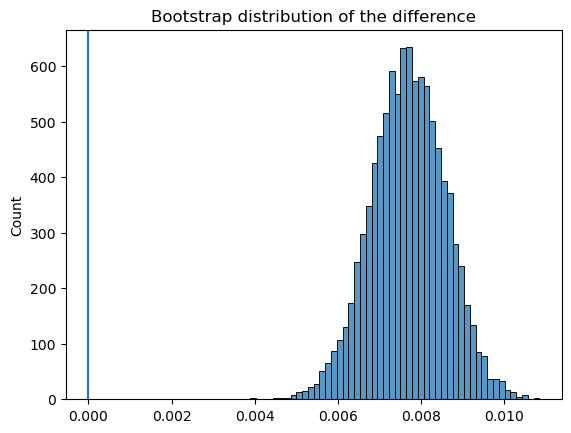

In [24]:
# Visualisation
sns.histplot(boot_diff, bins=50)
plt.axvline(0, linestyle='-')
plt.title("Bootstrap distribution of the difference")
plt.show()

### Statictical Power 

In [25]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# conversion rates
p1 = cr["ad"]
p2 = cr["psa"]

# effect size
effect_size = proportion_effectsize(p1, p2)

# sample sizes
n1 = users["ad"]
n2 = users["psa"]

ratio = n2 / n1

# power analysis
power_analysis = NormalIndPower()

power = power_analysis.power(
    effect_size=effect_size,
    nobs1=n1,
    alpha=0.05,
    ratio=ratio
)

round(power,4)

1.0

The statistical power of the experiment is very high, the sample size is sufficient to detect the observed difference in conversion rates.

### Segment Analysis

#### Time of the day

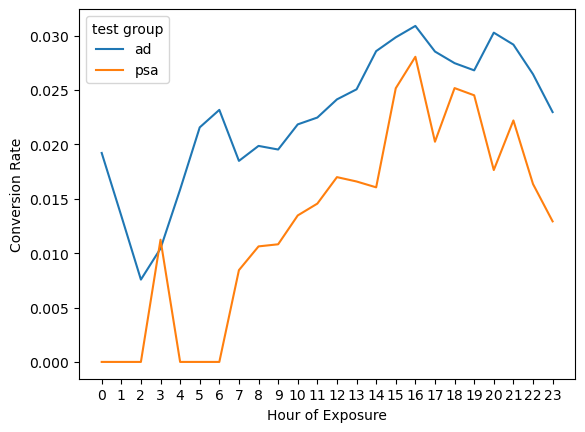

In [26]:
cr_hour = data.groupby(["most ads hour", "test group"])["converted"].mean().reset_index()

sns.lineplot(
    data=cr_hour,
    x="most ads hour",
    y="converted",
    hue="test group"
)

plt.ylabel("Conversion Rate")
plt.xlabel("Hour of Exposure")
plt.xticks(range(0,24)) 

plt.show()

In [27]:
# Lift during the day
cr_hour_pivot = cr_hour.pivot(
    index="most ads hour",
    columns="test group",
    values="converted"
)


In [28]:
cr_hour_pivot["lift"] = (
    (cr_hour_pivot["ad"] - cr_hour_pivot["psa"]) /
    cr_hour_pivot["psa"]
) * 100

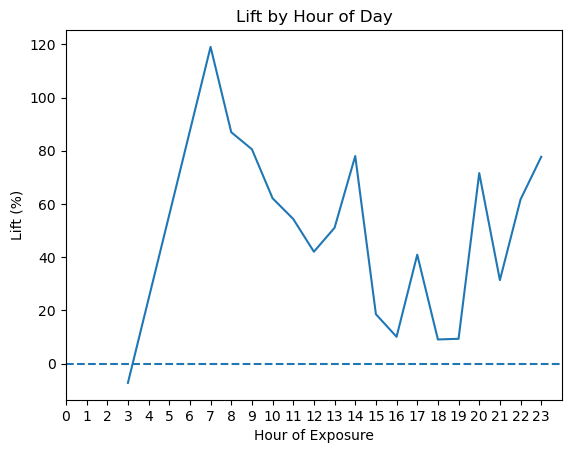

In [29]:
sns.lineplot(
    data=cr_hour_pivot.reset_index(),
    x="most ads hour",
    y="lift"
)

plt.axhline(0, linestyle="--")

plt.ylabel("Lift (%)")
plt.xlabel("Hour of Exposure")
plt.title("Lift by Hour of Day")

plt.xticks(range(0,24))

plt.show()

Overall, the results suggest that advertisements appear to perform particularly well during afternoon and evening hours, which may represent periods of higher user engagement.

The campaign lift varies in different hours of the day, suggesting that the effectiveness of advertisements may depend on the timing of exposure. The lift remains mostly positive, indicating that advertisements improve conversion probability relative to the PSA condition.

#### Day of the weeks 

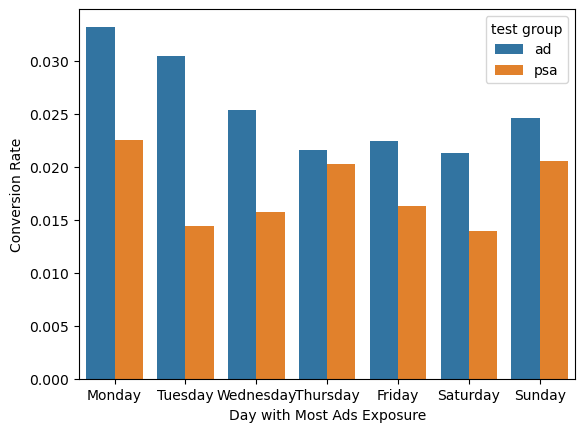

In [30]:
cr_day = data.groupby(["most ads day", "test group"])["converted"].mean().reset_index()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.barplot(
    data=cr_day,
    x="most ads day",
    y="converted",
    hue="test group",
    order=day_order
)

plt.ylabel("Conversion Rate")
plt.xlabel("Day with Most Ads Exposure")

plt.show()

The conversion rate varies slightly across the days. However, the advertisement campaign is effective throughout the week and does not appear to be limited to a specific day.

### Logistic Regression

In [31]:
# time of the day should not be treated as a continonus variable it will be transfomred into buckets 
data["hour_group"] = pd.cut(
    data["most ads hour"],
    bins=[0,6,12,18,24],
    labels=["night","morning","afternoon","evening"],
    right=False
)

In [32]:
data["hour_group"].value_counts()

hour_group
afternoon    257839
evening      168172
morning      142253
night         19837
Name: count, dtype: int64

In [33]:
data.columns = data.columns.str.replace(" ", "_")

In [34]:
data["converted"] = data["converted"].astype(int)

In [35]:
import statsmodels.formula.api as smf

model = smf.logit(
    "converted ~ C(test_group) + total_ads + C(most_ads_day) + C(hour_group)",
    data=data
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.108269
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588089
Method:                           MLE   Df Model:                           11
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                 0.08076
Time:                        17:58:43   Log-Likelihood:                -63673.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -4.9799      0.070    -71.631      0.000      -5.116      -4.844
C(test_group)[T.psa]            -0.3853      0.052     -7.473      0.000      -0.486      -0.284
C(most_ads_day)[T.Monday]        0.4633      0.031     15.106      0.000       0.403       0.523
C(most_ads_day)[T.Saturday]      0.0209      0.034      0.610      0.542      -0.046       0.088
C(most_ads_day)[T.Sunday]        0.2107      0.033      6.466      0.000       0.147       0.275
C(most_ads_day)[T.Thursday]      0.0592      0.034      1.740      0.082      -0.007       0.126
C(most_ads_day)[T.Tuesday]       0.4310      0.032     13.482      0.000       0.368       0.494
C(most_ads_day)[T.Wednesday]     0.1999      0.033      6.035      0.000       0.135       0.265
C(hour_group)[T.morning]         0.4831      0.068      7.053      0.000       0.349       0.617
C(hour_group)[T.afternoon]       0.8127      0.067     12.154      0.000       0.682       0.944
C(hour_group)[T.evening]         0.8278      0.067     12.269      0.000       0.696       0.960
total_ads                        0.0103   9.91e-05    103.404      0.000       0.010       0.010
================================================================================================
"""

### Model interpretation

- The coefficient for the PSA group is negative and statistically significant, indicating that users exposed to the public service announcement (control group) have a lower probability of conversion compared to users exposed to advertisements (treatment group).
- The number of advertisements seen by the user has a positive and statistically significant association with conversion probability, suggesting that greater ad exposure increases the likelihood of purchase.
- Conversion probability varies across different times of the day, with afternoon and evening hours showing the strongest positive association with conversion.
- Some variation in conversion probability is also observed across days of the week.

The overall results suggest that the positive effect observed in the A/B test is robust and not driven solely by temporal patterns in user behavior.
